In [2]:
# 环境与数据
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

BASE = Path(".").resolve()
DATA = BASE.parent / "data"  # 仓库根目录 data/
OUT = BASE / "figures"
OUT.mkdir(parents=True, exist_ok=True)

G = ["#C8E6C9", "#81C784", "#66BB6A", "#43A047", "#2E7D32", "#1B5E20"]
TEAL = "#00796B"
RED = "#C62828"
TEXT = "#1B3D2F"
MUTED = "#5A7A6A"
BG = "#F1F8F4"

plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.facecolor": BG,
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": MUTED,
    "axes.labelcolor": TEXT,
    "text.color": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#D7E8DC",
})

orders = pd.read_csv(DATA / "FMart_订单明细.csv")
members = pd.read_csv(DATA / "FMart_会员信息.csv")
stores = pd.read_csv(DATA / "FMart_门店信息.csv")
products = pd.read_csv(DATA / "FMart_商品目录.csv")
categories = pd.read_csv(DATA / "FMart_品类字典.csv")
behaviors = pd.read_csv(DATA / "FMart_会员行为明细.csv")
orders["订单日期"] = pd.to_datetime(orders["订单日期"])

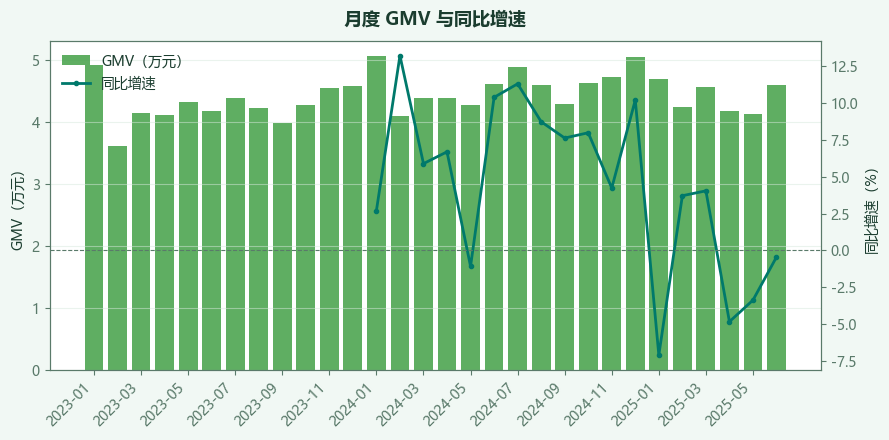

In [3]:
# 图1 · 月度 GMV 与同比增速
_orders = orders.copy()
_orders["ym"] = _orders["订单日期"].dt.to_period("M")
monthly = _orders.groupby("ym")["订单金额_元"].sum().sort_index()
monthly.index = monthly.index.astype(str)
yoy = monthly.pct_change(12) * 100

fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(monthly))
ax1.bar(x, monthly.values / 10000, color=G[3], alpha=0.85, label="GMV（万元）")
ax1.set_ylabel("GMV（万元）")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax2 = ax1.twinx()
ax2.plot(x, yoy.values, color=TEAL, marker="o", markersize=3, linewidth=2, label="同比增速")
ax2.axhline(0, color=MUTED, linewidth=0.8, linestyle="--")
ax2.set_ylabel("同比增速（%）")
step = max(1, len(x) // 12)
ax1.set_xticks(x[::step])
ax1.set_xticklabels(monthly.index[::step], rotation=45, ha="right")
ax1.set_title("月度 GMV 与同比增速", fontsize=13, fontweight="bold", pad=12)
ax1.grid(axis="y", alpha=0.5)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig(OUT / "fig01_monthly_gmv_yoy.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

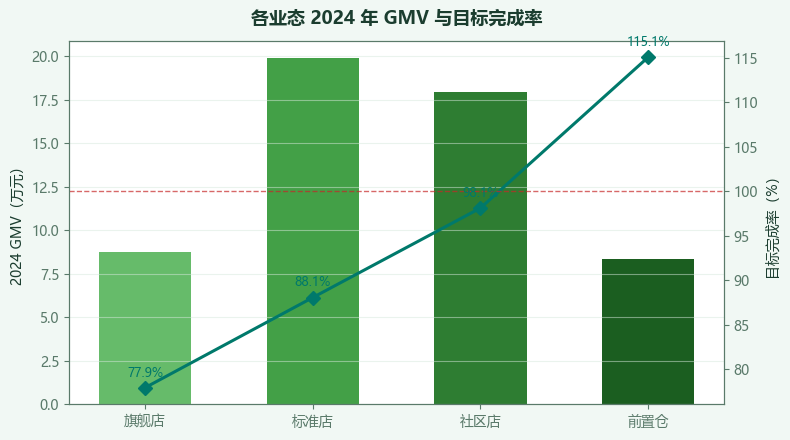

In [4]:
# 图2 · 各业态 2024 年 GMV 与目标完成率
o2024 = orders[orders["订单日期"].dt.year == 2024]
rows = []
for st in ["旗舰店", "标准店", "社区店", "前置仓"]:
    ids = stores[stores["门店类型"] == st]["门店ID"]
    gmv = o2024[o2024["门店ID"].isin(ids)]["订单金额_元"].sum()
    target = stores[stores["门店类型"] == st]["年度GMV目标_元"].sum()
    rows.append({"门店类型": st, "GMV": gmv, "完成率": gmv / target * 100})
df = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(df))
ax1.bar(x, df["GMV"] / 10000, color=[G[2], G[3], G[4], G[5]], width=0.55)
ax1.set_ylabel("2024 GMV（万元）")
ax1.set_xticks(x)
ax1.set_xticklabels(df["门店类型"])
ax2 = ax1.twinx()
ax2.plot(x, df["完成率"], color=TEAL, marker="D", linewidth=2.2, markersize=7, label="目标完成率")
ax2.axhline(100, color=RED, linewidth=1, linestyle="--", alpha=0.7)
ax2.set_ylabel("目标完成率（%）")
for i, v in enumerate(df["完成率"]):
    ax2.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=9, color=TEAL)
ax1.set_title("各业态 2024 年 GMV 与目标完成率", fontsize=13, fontweight="bold", pad=12)
ax1.grid(axis="y", alpha=0.5)
fig.tight_layout()
fig.savefig(OUT / "fig02_store_type_performance.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

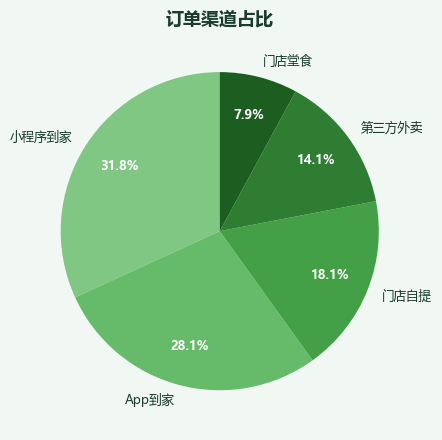

In [5]:
# 图3 · 订单渠道占比
ch = orders["订单渠道"].value_counts()
labels = ch.index.tolist()
sizes = ch.values
colors = G[1:1 + len(labels)]

fig, ax = plt.subplots(figsize=(7, 4.5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%", startangle=90,
    colors=colors, pctdistance=0.75, textprops={"fontsize": 9},
)
for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")
ax.set_title("订单渠道占比", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT / "fig03_channel_share.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

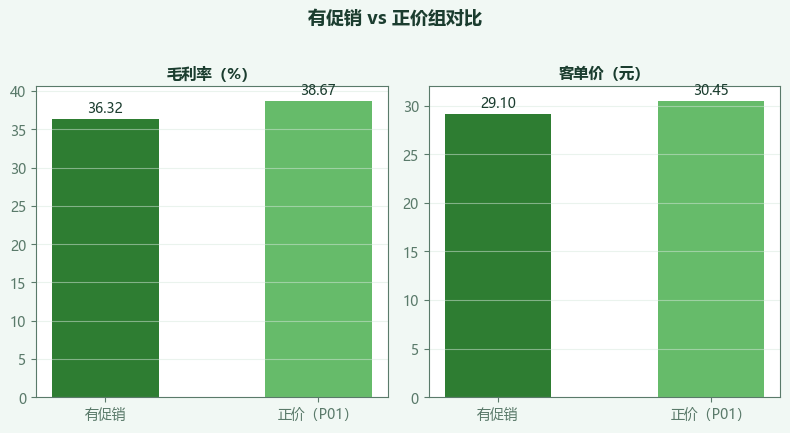

In [6]:
# 图4 · 有促销 vs 正价组对比
promo = orders[orders["促销ID"] != "P01"]
nop = orders[orders["促销ID"] == "P01"]
metrics = {
    "毛利率（%）": [
        promo["毛利_元"].sum() / promo["订单金额_元"].sum() * 100,
        nop["毛利_元"].sum() / nop["订单金额_元"].sum() * 100,
    ],
    "客单价（元）": [promo["订单金额_元"].mean(), nop["订单金额_元"].mean()],
}
labels = ["有促销", "正价（P01）"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
for ax, (title, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=[G[4], G[2]], width=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.5)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.2f}", (b.get_x() + b.get_width() / 2, v),
                    textcoords="offset points", xytext=(0, 5), ha="center", fontsize=10)
fig.suptitle("有促销 vs 正价组对比", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "fig04_promo_comparison.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

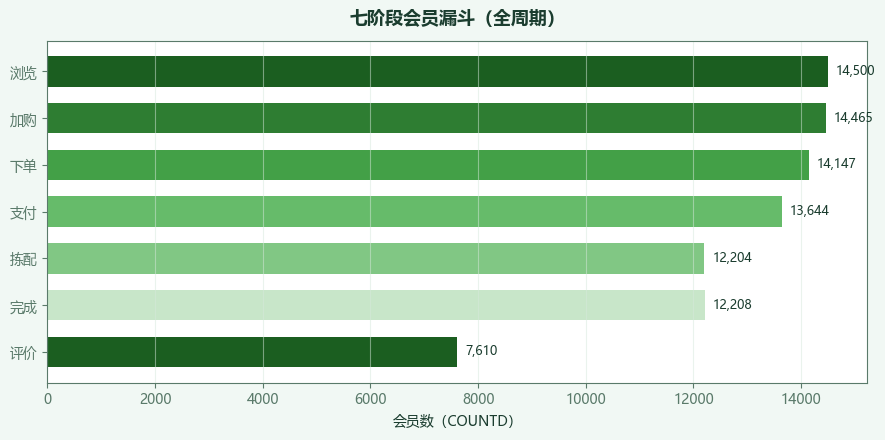

In [7]:
# 图5 · 七阶段会员漏斗
stages = ["浏览", "加购", "下单", "支付", "拣配", "完成", "评价"]
counts = [behaviors[behaviors["事件类型"] == s]["会员ID"].nunique() for s in stages]

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(stages))
bars = ax.barh(y, counts, color=G[::-1][:7], height=0.65)
ax.set_yticks(y)
ax.set_yticklabels(stages)
ax.invert_yaxis()
ax.set_xlabel("会员数（COUNTD）")
for b, c in zip(bars, counts):
    ax.text(c + max(counts) * 0.01, b.get_y() + b.get_height() / 2,
            f"{c:,}", va="center", fontsize=9)
ax.set_title("七阶段会员漏斗（全周期）", fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.5)
fig.tight_layout()
fig.savefig(OUT / "fig05_funnel.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

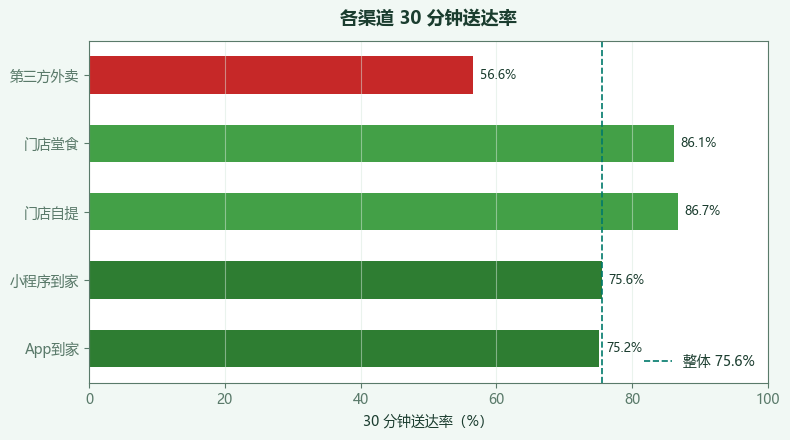

In [8]:
# 图6 · 各渠道 30 分钟送达率
ch_order = ["App到家", "小程序到家", "门店自提", "门店堂食", "第三方外卖"]
rates = []
for ch in ch_order:
    sub = orders[orders["订单渠道"] == ch]
    rates.append((sub["配送时长_分钟"] <= 30).mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [RED if r < 70 else G[4] if r < 80 else G[3] for r in rates]
bars = ax.barh(ch_order, rates, color=colors, height=0.55)
ax.axvline(75.6, color=TEAL, linestyle="--", linewidth=1.2, label="整体 75.6%")
ax.set_xlabel("30 分钟送达率（%）")
ax.set_xlim(0, 100)
for b, r in zip(bars, rates):
    ax.text(r + 1, b.get_y() + b.get_height() / 2, f"{r:.1f}%", va="center", fontsize=9)
ax.set_title("各渠道 30 分钟送达率", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="x", alpha=0.5)
fig.tight_layout()
fig.savefig(OUT / "fig06_delivery_sla.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

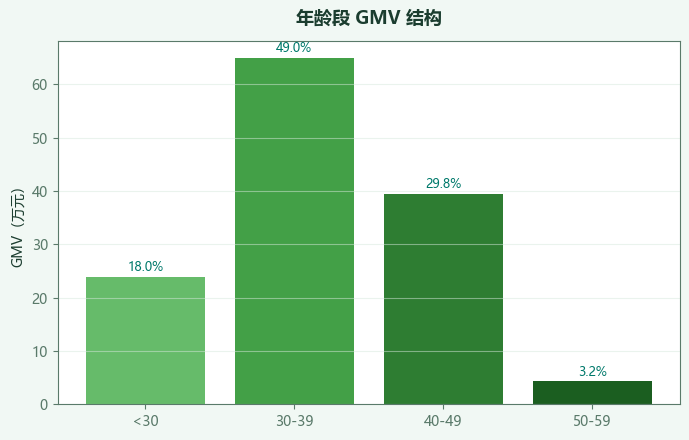

In [9]:
# 图7 · 年龄段 GMV 结构
m = orders.merge(members, on="会员ID")
m["年龄段"] = pd.cut(
    m["年龄"], bins=[0, 29, 39, 49, 59, 100],
    labels=["<30", "30-39", "40-49", "50-59", "60+"],
)
gmv = m.groupby("年龄段", observed=True)["订单金额_元"].sum()
pct = gmv / gmv.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(gmv.index.astype(str), gmv.values / 10000, color=G[2:7])
ax.set_ylabel("GMV（万元）")
ax.set_title("年龄段 GMV 结构", fontsize=13, fontweight="bold", pad=12)
for b, p in zip(bars, pct):
    ax.annotate(f"{p:.1f}%", (b.get_x() + b.get_width() / 2, b.get_height()),
                textcoords="offset points", xytext=(0, 4), ha="center", fontsize=9, color=TEAL)
ax.grid(axis="y", alpha=0.5)
fig.tight_layout()
fig.savefig(OUT / "fig07_age_gmv.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()

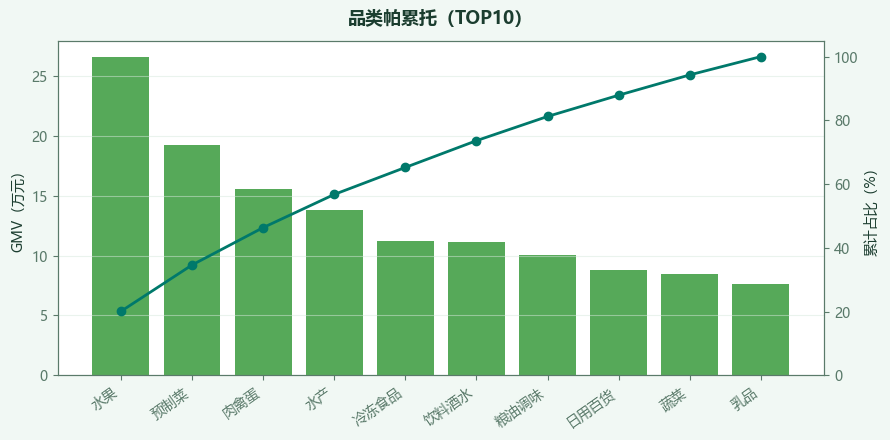

In [10]:
# 图8 · 品类帕累托 TOP10
p = products.merge(categories, on="品类ID")
om = orders.merge(p[["商品ID", "一级品类"]], on="商品ID")
gmv = om.groupby("一级品类")["订单金额_元"].sum().sort_values(ascending=False)
cum = gmv / gmv.sum() * 100
cum_pct = cum.cumsum()
top = gmv.head(10)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(top))
ax1.bar(x, top.values / 10000, color=G[3], alpha=0.9)
ax1.set_ylabel("GMV（万元）")
ax1.set_xticks(x)
ax1.set_xticklabels(top.index, rotation=35, ha="right")
ax2 = ax1.twinx()
ax2.plot(x, cum_pct[top.index].values, color=TEAL, marker="o", linewidth=2)
ax2.set_ylabel("累计占比（%）")
ax2.set_ylim(0, 105)
ax1.set_title("品类帕累托（TOP10）", fontsize=13, fontweight="bold", pad=12)
ax1.grid(axis="y", alpha=0.5)
fig.tight_layout()
fig.savefig(OUT / "fig08_category_pareto.png", dpi=160, bbox_inches="tight", facecolor=BG)
plt.show()